In [54]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [9]:
# Cell 1: Environment Setup and Imports
%load_ext cython
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, Any, Optional, List, Tuple
import warnings
import json
import time
from pathlib import Path
import threading
import queue
import concurrent.futures
import requests
import hashlib
import pickle
import os
from dataclasses import dataclass, asdict
from abc import ABC, abstractmethod

warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=== ENHANCED LLM-INTEGRATED ENVIRONMENT ===")

The cython extension is already loaded. To reload it, use:
  %reload_ext cython
=== ENHANCED LLM-INTEGRATED ENVIRONMENT ===


In [10]:
# Cell 2: Instance-Specific Configuration Manager
class InstanceSpecificConfigManager:
    """Manages configurations for different problem instances (Inspired by InstSpecHH)"""
    
    def __init__(self):
        self.instance_features = {}
        self.config_registry = {}
        self.performance_history = {}
        self.best_configs = {}
        
    def extract_instance_features(self, instance_file, weights_file, nbitems, num_objectives):
        """Extract key features from problem instance"""
        features = {
            'n_items': nbitems,
            'n_objectives': num_objectives,
            'instance_size': 'small' if nbitems <= 250 else 'medium' if nbitems <= 500 else 'large',
            'complexity': num_objectives * nbitems / 1000
        }
        
        # Try to extract more features from files
        try:
            with open(instance_file, 'r') as f:
                lines = f.readlines()
                if len(lines) > 0:
                    first_line = lines[0].strip()
                    if first_line:
                        parts = first_line.split()
                        if len(parts) >= 2:
                            features['n_objectives'] = int(parts[0])
                            features['n_items'] = int(parts[1])
            
            # Calculate capacity ratio
            with open(instance_file, 'r') as f:
                lines = f.readlines()
                if len(lines) > 1:
                    capacity_line = lines[1].strip()
                    if capacity_line:
                        capacity = float(capacity_line)
                        features['capacity_ratio'] = capacity / nbitems
        except:
            features['capacity_ratio'] = 0.5  # Default value
        
        # Create instance signature
        signature = f"{features['n_items']}_{features['n_objectives']}"
        features['signature'] = signature
        
        self.instance_features[signature] = features
        return features
    
    def get_best_config_for_instance(self, instance_signature):
        """Get best configuration for a specific instance type"""
        if instance_signature in self.best_configs:
            return self.best_configs[instance_signature]
        
        # Default configurations based on instance type
        if '250' in instance_signature:
            return {
                'alpha': 35, 'kappa': 0.12, 'L': 5,
                'operator_strategy': ['swap', 'greedy_add', 'mutation'],
                'runtime_threshold': 7.0
            }
        elif '500' in instance_signature:
            return {
                'alpha': 40, 'kappa': 0.15, 'L': 6,
                'operator_strategy': ['swap', 'greedy_add', 'local_search'],
                'runtime_threshold': 10.0
            }
        elif '750' in instance_signature:
            return {
                'alpha': 45, 'kappa': 0.18, 'L': 7,
                'operator_strategy': ['swap', 'greedy_add', 'mutation'],
                'runtime_threshold': 12.0
            }
        else:
            return {
                'alpha': 40, 'kappa': 0.15, 'L': 6,
                'operator_strategy': ['swap', 'greedy_add', 'mutation'],
                'runtime_threshold': 10.0
            }
    
    def update_best_config(self, instance_signature, config, performance):
        """Update best configuration for an instance type"""
        if instance_signature not in self.best_configs:
            self.best_configs[instance_signature] = config.copy()
            return
        
        # Update if performance is better
        current_best = self.best_configs[instance_signature]
        if performance > self.performance_history.get(instance_signature, {}).get('best_performance', 0):
            self.best_configs[instance_signature] = config.copy()
            self.performance_history[instance_signature] = {
                'best_performance': performance,
                'config': config.copy(),
                'timestamp': time.time()
            }

# Initialize instance-specific config manager
instance_config_manager = InstanceSpecificConfigManager()


In [11]:
# Cell 3: Enhanced LLM Interface with Better Parameter Exploration
class ImprovedLLMInterface:
    """Enhanced LLM interface with better parameter exploration"""
    
    def __init__(self, model_path="llama3:latest", temperature=0.8, max_tokens=500):
        self.model_path = model_path
        self.temperature = temperature  # Increased for more exploration
        self.max_tokens = max_tokens
        self.cache = {}
        self.call_count = 0
        self.successful_calls = 0
        self.failed_calls = 0
        self.connection_status = None
        self.exploration_history = []  # Track explored parameters
        self._verify_connection()
        
    def _verify_connection(self):
        """Verify if LLaMA-3 is accessible"""
        try:
            response = requests.get('http://localhost:11434/api/tags', timeout=5)
            if response.status_code == 200:
                models = response.json().get('models', [])
                model_names = [model['name'] for model in models]
                
                if self.model_path in model_names:
                    self.connection_status = "ollama_connected"
                    print(f"✅ Ollama connected with {self.model_path} available")
                    return True
                else:
                    self.connection_status = "ollama_no_model"
                    return False
            else:
                self.connection_status = "ollama_failed"
        except Exception as e:
            self.connection_status = "ollama_unavailable"
        
        return False
    
    def _call_ollama(self, prompt):
        """Call local Ollama API for LLaMA-3"""
        try:
            response = requests.post(
                'http://localhost:11434/api/generate',
                json={
                    'model': self.model_path,
                    'prompt': prompt,
                    'stream': False,
                    'options': {
                        'temperature': self.temperature,
                        'num_predict': self.max_tokens,
                        'timeout': 30
                    }
                },
                timeout=120
            )
            if response.status_code == 200:
                self.successful_calls += 1
                return response.json()['response']
            else:
                self.failed_calls += 1
                return None
        except Exception as e:
            self.failed_calls += 1
            return None
    
    def generate_explorative_config(self, instance_features, current_performance, target_performance, explored_configs):
        """Generate more explorative configuration avoiding repetition"""
        
        if self.connection_status != "ollama_connected":
            return self._generate_explorative_rule_based_config(instance_features, current_performance, target_performance, explored_configs)
        
        # Calculate performance gap
        gap = target_performance - current_performance
        gap_percentage = (gap / target_performance) * 100
        
        # More aggressive prompt for exploration
        prompt = f"""
You are an expert in multi-objective optimization for knapsack problems.

INSTANCE FEATURES:
- Number of items: {instance_features['n_items']}
- Number of objectives: {instance_features['n_objectives']}
- Instance size: {instance_features['instance_size']}
- Complexity score: {instance_features['complexity']:.2f}

CURRENT PERFORMANCE:
- Current hypervolume: {current_performance:,.0f}
- Target hypervolume: {target_performance:,.0f}
- Performance gap: {gap:,.0f} ({gap_percentage:.1f}%)

PREVIOUSLY EXPLORED CONFIGS (AVOID THESE):
{list(explored_configs.keys())[:10]}  # Show first 10 to avoid prompt overflow

TASK:
Generate a NEW, EXPLORATIVE configuration that has NOT been tried before.
Focus on achieving significant improvement (target: 5%+ improvement).
Be BOLD with parameter changes - we need substantial improvement.

PARAMETER CONSTRAINTS:
- alpha (population size): 20-60 (explore widely)
- kappa (selection pressure): 0.03-0.25 (explore widely)
- L (local search intensity): 2-12 (explore widely)
- runtime_threshold: 5.0-15.0 (reasonable limits)

OPERATORS:
- swap: Exchange items in solution
- greedy_add: Add best feasible items
- mutation: Random modifications
- local_search: Neighborhood exploration

RESPONSE FORMAT (JSON only):
{{
    "alpha": <integer>,
    "kappa": <float with 3 decimals>,
    "L": <integer>,
    "operator_strategy": [<list of 2-3 operators>],
    "runtime_threshold": <float between 5.0 and 15.0>,
    "reasoning": "<brief explanation of why this config should work better>"
}}
"""
        
        response = self._call_ollama(prompt)
        
        if response:
            try:
                # Extract JSON from response
                start_idx = response.find('{')
                end_idx = response.rfind('}') + 1
                if start_idx != -1 and end_idx != -1:
                    json_str = response[start_idx:end_idx]
                    config = json.loads(json_str)
                    
                    # Validate and adjust parameters
                    config['alpha'] = min(60, max(20, int(config.get('alpha', 40))))
                    config['kappa'] = min(0.25, max(0.03, float(config.get('kappa', 0.15))))
                    config['L'] = min(12, max(2, int(config.get('L', 6))))
                    config['runtime_threshold'] = min(15.0, max(5.0, float(config.get('runtime_threshold', 7.0))))
                    
                    # Validate operators
                    valid_operators = ['swap', 'greedy_add', 'mutation', 'local_search']
                    strategy = config.get('operator_strategy', ['swap', 'greedy_add'])
                    config['operator_strategy'] = [op for op in strategy if op in valid_operators]
                    
                    if not config['operator_strategy']:
                        config['operator_strategy'] = ['swap', 'greedy_add', 'mutation']
                    
                    return config
            except json.JSONDecodeError:
                print("⚠️ Could not parse JSON from LLM response")
        
        # Fallback to rule-based
        return self._generate_explorative_rule_based_config(instance_features, current_performance, target_performance, explored_configs)
    
    def _generate_explorative_rule_based_config(self, instance_features, current_performance, target_performance, explored_configs):
        """Generate more explorative rule-based configuration"""
        
        gap = target_performance - current_performance
        gap_percentage = (gap / target_performance) * 100
        
        # More aggressive exploration based on gap
        if gap_percentage > 8:  # Large gap - be very aggressive
            alpha_options = [45, 50, 55, 60]
            kappa_options = [0.18, 0.20, 0.22, 0.25]
            L_options = [7, 8, 9, 10, 12]
        elif gap_percentage > 4:  # Medium gap - moderately aggressive
            alpha_options = [35, 40, 45, 50]
            kappa_options = [0.12, 0.15, 0.18, 0.20]
            L_options = [5, 6, 7, 8, 9]
        else:  # Small gap - fine-tune aggressively
            alpha_options = [25, 30, 35, 40, 45]
            kappa_options = [0.08, 0.10, 0.12, 0.15, 0.18]
            L_options = [3, 4, 5, 6, 7, 8]
        
        # Try to find unexplored configuration
        max_attempts = 20
        for _ in range(max_attempts):
            alpha = np.random.choice(alpha_options)
            kappa = np.random.choice(kappa_options)
            L = np.random.choice(L_options)
            
            # Create config signature
            config_sig = f"{alpha}_{kappa:.3f}_{L}"
            
            # Check if this configuration was explored
            if config_sig not in explored_configs:
                # Select operators based on instance type
                if instance_features['n_objectives'] == 2:
                    if gap_percentage > 6:
                        operator_strategy = ['swap', 'greedy_add', 'local_search']
                    else:
                        operator_strategy = ['swap', 'greedy_add', 'mutation']
                else:
                    operator_strategy = ['swap', 'greedy_add', 'local_search']
                
                # Runtime threshold based on instance size
                if instance_features['instance_size'] == 'small':
                    runtime_threshold = 7.0
                elif instance_features['instance_size'] == 'medium':
                    runtime_threshold = 10.0
                else:
                    runtime_threshold = 12.0
                
                return {
                    'alpha': alpha,
                    'kappa': kappa,
                    'L': L,
                    'operator_strategy': operator_strategy,
                    'runtime_threshold': runtime_threshold,
                    'reasoning': f'Explorative rule-based config for {gap_percentage:.1f}% gap'
                }
        
        # If all configurations explored, return a modified version of the best
        if explored_configs:
            best_config = max(explored_configs.items(), key=lambda x: x[1]['performance'])[1]
            return {
                'alpha': min(60, best_config['alpha'] + 5),
                'kappa': min(0.25, best_config['kappa'] + 0.02),
                'L': min(12, best_config['L'] + 1),
                'operator_strategy': best_config['operator_strategy'],
                'runtime_threshold': best_config['runtime_threshold'],
                'reasoning': 'Modified best explored config'
            }
        
        # Default fallback
        return {
            'alpha': 40,
            'kappa': 0.15,
            'L': 6,
            'operator_strategy': ['swap', 'greedy_add', 'mutation'],
            'runtime_threshold': 7.0,
            'reasoning': 'Default explorative config'
        }


In [12]:
# Cell 4: Reference Hypervolume Calculator
def calculate_hypervolume_2d(pareto_front, reference_point=None):
    """Calculate 2D hypervolume of Pareto front"""
    if len(pareto_front) == 0:
        return 0.0
    if reference_point is None:
        reference_point = np.array([0.0, 0.0])
    sorted_front = pareto_front[np.argsort(pareto_front[:, 0])]
    hypervolume = 0.0
    prev_x = reference_point[0]
    for point in sorted_front:
        width = point[0] - prev_x
        height = point[1] - reference_point[1]
        if width > 0 and height > 0:
            hypervolume += width * height
        prev_x = point[0]
    return hypervolume

def calculate_reference_hv_for_instance(result_file):
    """Calculate reference hypervolume for a specific instance result file"""
    try:
        # Load the results
        data = np.loadtxt(result_file)
        if data.ndim == 1:
            data = data.reshape(1, -1)
        
        # Remove duplicates
        data_unique = np.unique(data, axis=0)
        
        # Extract Pareto front (maximization)
        def is_pareto_efficient(points):
            is_efficient = np.ones(points.shape[0], dtype=bool)
            for i, c in enumerate(points):
                if is_efficient[i]:
                    is_efficient[is_efficient] = np.any(points[is_efficient]>=c, axis=1)
                    is_efficient[i] = True
            return is_efficient
        
        pareto_mask = is_pareto_efficient(data_unique)
        pareto_points = data_unique[pareto_mask]
        
        # Calculate hypervolume
        hv = calculate_hypervolume_2d(pareto_points)
        
        return {
            'all_solutions': data,
            'unique_solutions': data_unique,
            'pareto_solutions': pareto_points,
            'num_pareto': len(pareto_points),
            'hypervolume': hv
        }
    except Exception as e:
        print(f"Error loading result file {result_file}: {e}")
        return None

# Calculate reference hypervolumes for all instances
reference_hvs = {}
instance_files = [
    ("250_2", "2502_Results.txt"),
    ("500_2", "5002_Results.txt"),
    ("750_2", "7502_Results.txt")
]

print("Calculating reference hypervolumes for all instances...")
for instance_sig, result_file in instance_files:
    print(f"Processing {result_file}...")
    ref_data = calculate_reference_hv_for_instance(result_file)
    if ref_data:
        reference_hvs[instance_sig] = ref_data
        print(f"✓ {instance_sig}: HV = {ref_data['hypervolume']:,.0f}, Pareto points = {ref_data['num_pareto']}")
    else:
        print(f"❌ Failed to process {result_file}")

print("\nReference hypervolumes calculated successfully!")


Calculating reference hypervolumes for all instances...
Processing 2502_Results.txt...
✓ 250_2: HV = 98,522,052, Pareto points = 315
Processing 5002_Results.txt...
✓ 500_2: HV = 406,753,182, Pareto points = 558
Processing 7502_Results.txt...
✓ 750_2: HV = 890,575,382, Pareto points = 886

Reference hypervolumes calculated successfully!


In [14]:
%%cython
"""
Enhanced MOACP Implementation with Instance-Specific Optimization
"""

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import numpy as np
import time

# Structs
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# Enhanced operators with better performance
cdef void enhanced_swap_operator(pop *SP, pop *Sarchive, int size, double time_budget):
    cdef ind *x
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef double start_time = time.time()
    cdef double current_time
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    cdef int no_improvement_count = 0
    cdef double best_hv = 0.0
    
    while (time.time() - start_time) < time_budget * 0.9 and no_improvement_count < 3:
        convergence = 0
        for i in range(SP.size):
            current_time = time.time()
            
            if (current_time - start_time) > time_budget * 0.9:
                break
                
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr and (current_time - start_time) < time_budget * 0.9:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L and (current_time - start_time) < time_budget * 0.9:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            no_improvement_count += 1
        else:
            no_improvement_count = 0
    free(remplace)

cdef void enhanced_greedy_add_operator(pop *SP, pop *Sarchive, int size, double time_budget):
    cdef int i, best_item, r
    cdef double best_gain, gain
    cdef ind *x
    cdef double start_time = time.time()
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    for i in range(SP.size):
        if (time.time() - start_time) > time_budget * 0.9:
            break
            
        x = ind_copy(SP.ind_array[i])
        best_item = -1
        best_gain = -1.0
        for j in range(ni):
            if (time.time() - start_time) > time_budget * 0.9:
                break
                
            if x.Items[j] == 0:
                feasible = 1
                for r in range(nf):
                    if x.capa[r] + weights[r][j] > capacities[r]:
                        feasible = 0
                        break
                if feasible:
                    gain = 0.0
                    for r in range(nf):
                        gain += profits[r][j]
                    if gain > best_gain:
                        best_gain = gain
                        best_item = j
        if best_item != -1:
            x.Items[best_item] = 1
            x.nombr += 1
            x.nombr_nonpris -= 1
            for r in range(nf):
                x.capa[r] += weights[r][best_item]
                x.f[r] += profits[r][best_item]
            for r in range(nf):
                x.v[r] = x.f[r] * vector_weight[r]
            max_bound = calcMaxbound(SP, SP.size)
            compute_fitness_and_select(SP, x, SP.size)
        free_ind(x)

cdef void enhanced_mutation_operator(pop *SP, pop *Sarchive, int size, double time_budget):
    cdef ind *x
    cdef int i, j, r, mutation_count
    cdef double start_time = time.time()
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    for i in range(SP.size):
        if (time.time() - start_time) > time_budget * 0.9:
            break
            
        x = ind_copy(SP.ind_array[i])
        
        # Adaptive mutation count based on problem size
        mutation_count = max(1, ni // 50)
        
        for m in range(mutation_count):
            if (time.time() - start_time) > time_budget * 0.9:
                break
                
            j = irand(ni)
            
            if x.Items[j] == 1:
                # Remove item
                x.Items[j] = 0
                x.nombr -= 1
                x.nombr_nonpris += 1
                for r in range(nf):
                    x.capa[r] -= weights[r][j]
                    x.f[r] -= profits[r][j]
            else:
                # Try to add item
                feasible = 1
                for r in range(nf):
                    if x.capa[r] + weights[r][j] > capacities[r]:
                        feasible = 0
                        break
                if feasible:
                    x.Items[j] = 1
                    x.nombr += 1
                    x.nombr_nonpris -= 1
                    for r in range(nf):
                        x.capa[r] += weights[r][j]
                        x.f[r] += profits[r][j]
        
        # Update weighted objectives
        for r in range(nf):
            x.v[r] = x.f[r] * vector_weight[r]
        
        max_bound = calcMaxbound(SP, SP.size)
        compute_fitness_and_select(SP, x, SP.size)
        free_ind(x)

cdef void enhanced_local_search_operator(pop *SP, pop *Sarchive, int size, double time_budget):
    cdef ind *x
    cdef int i, j, r, best_item, remove_item
    cdef double best_gain, gain, current_hv, best_hv
    cdef double start_time = time.time()
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    for i in range(SP.size):
        if (time.time() - start_time) > time_budget * 0.9:
            break
            
        x = ind_copy(SP.ind_array[i])
        current_hv = 0.0
        for r in range(nf):
            current_hv += x.f[r] * vector_weight[r]
        
        best_hv = current_hv
        best_item = -1
        remove_item = -1
        
        # Try to add one item and remove one item
        for add_j in range(ni):
            if (time.time() - start_time) > time_budget * 0.9:
                break
                
            if x.Items[add_j] == 0:
                # Check if we can add this item
                feasible = 1
                for r in range(nf):
                    if x.capa[r] + weights[r][add_j] > capacities[r]:
                        feasible = 0
                        break
                
                if feasible:
                    # Try removing each item to make room
                    for rem_j in range(ni):
                        if x.Items[rem_j] == 1:
                            # Calculate new hypervolume
                            new_hv = current_hv
                            
                            # Remove item
                            for r in range(nf):
                                new_hv -= weights[r][rem_j] * vector_weight[r]
                                new_hv -= profits[r][rem_j] * vector_weight[r]
                            
                            # Add item
                            for r in range(nf):
                                new_hv += weights[r][add_j] * vector_weight[r]
                                new_hv += profits[r][add_j] * vector_weight[r]
                            
                            if new_hv > best_hv:
                                best_hv = new_hv
                                best_item = add_j
                                remove_item = rem_j
        
        # Apply the best move found
        if best_item != -1 and remove_item != -1:
            # Remove item
            x.Items[remove_item] = 0
            x.nombr -= 1
            x.nombr_nonpris += 1
            for r in range(nf):
                x.capa[r] -= weights[r][remove_item]
                x.f[r] -= profits[r][remove_item]
            
            # Add item
            x.Items[best_item] = 1
            x.nombr += 1
            x.nombr_nonpris -= 1
            for r in range(nf):
                x.capa[r] += weights[r][best_item]
                x.f[r] += profits[r][best_item]
            
            # Update weighted objectives
            for r in range(nf):
                x.v[r] = x.f[r] * vector_weight[r]
            
            max_bound = calcMaxbound(SP, SP.size)
            compute_fitness_and_select(SP, x, SP.size)
        
        free_ind(x)

# Enhanced parameter configuration
cdef void set_enhanced_parameters(
    object custom_params=None, 
    object operator_strategy=None, 
    bint print_params=True
):
    global alpha, kappa, L, smallValue
    
    if custom_params is not None:
        # Apply enhanced bounds with validation
        new_alpha = int(custom_params.get('alpha', 40))
        new_kappa = float(custom_params.get('kappa', 0.15))
        new_L = int(custom_params.get('L', 6))
        new_small_value = float(custom_params.get('small_value', 1e-7))
        
        # Validate bounds
        alpha = min(60, max(20, new_alpha))
        kappa = min(0.25, max(0.03, new_kappa))
        L = min(12, max(2, new_L))
        smallValue = min(1e-6, max(1e-9, new_small_value))
        
        if print_params:
            print(f"🚀 Enhanced Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    else:
        alpha = 40
        kappa = 0.15
        L = 6
        smallValue = 1e-7
        if print_params:
            print(f"📊 Default Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    
    if operator_strategy is not None:
        print(f"   Operator strategy: {operator_strategy}")

# Enhanced main MOACP runner
def run_moacp_enhanced(
    instance_file,
    weights_file,
    nbitems,
    num_objectives,
    custom_params=None,
    operator_strategy=None,
    print_params=True,
    runtime_threshold=7.0,
    num_runs=8,
    num_iterations=100
):
    """
    Enhanced MOACP runner with instance-specific optimization
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    set_enhanced_parameters(custom_params, operator_strategy, print_params)
    NBITEMS = nbitems
    ni = nbitems
    nf = num_objectives
    paretoIni = 28000

    all_pareto_solutions = []
    run_times = []

    if print_params:
        print(f"\n Enhanced MOACP: {num_runs} runs × {num_iterations} iterations")
        print(f" Runtime threshold: {runtime_threshold:.2f}s per run")

    total_start_time = time.time()

    for run in range(1, num_runs + 1):
        run_start_time = time.time()
        if print_params:
            print(f"   Run {run}/{num_runs}...", end=" ")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file.encode())
        read_weights_file(weights_file.encode())

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)

        it = 0
        while it < num_iterations:
            iteration_start = time.time()
            
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)

            # Enhanced operator dispatch with time management
            if operator_strategy is not None and isinstance(operator_strategy, (list, tuple)):
                time_budget = runtime_threshold * 0.6 / len(operator_strategy)
                
                for op in operator_strategy:
                    op_start = time.time()
                    
                    # Skip operator if time budget exceeded
                    if (time.time() - iteration_start) > runtime_threshold * 0.8:
                        break
                    
                    # Enhanced operator mapping
                    if op == "swap":
                        enhanced_swap_operator(solutions, archive, alpha, time_budget)
                    elif op == "greedy_add":
                        enhanced_greedy_add_operator(solutions, archive, alpha, time_budget)
                    elif op == "mutation":
                        enhanced_mutation_operator(solutions, archive, alpha, time_budget)
                    elif op == "local_search":
                        enhanced_local_search_operator(solutions, archive, alpha, time_budget)
                    else:
                        enhanced_swap_operator(solutions, archive, alpha, time_budget)
            else:
                enhanced_swap_operator(solutions, archive, alpha, runtime_threshold * 0.6)

            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Extract Pareto front for this run
        run_pareto = []
        for i in range(P.size):
            if P.ind_array[i] != NULL:
                obj1 = P.ind_array[i].f[0]
                obj2 = P.ind_array[i].f[1] if nf > 1 else 0
                run_pareto.append([obj1, obj2])

        all_pareto_solutions.extend(run_pareto)
        pareto_np = np.array(run_pareto)
        if pareto_np.shape[0] > 0:
            max_obj1 = np.max(pareto_np[:, 0])
            min_obj1 = np.min(pareto_np[:, 0])
            spread_obj1 = max_obj1 - min_obj1
            max_obj2 = np.max(pareto_np[:, 1])
            min_obj2 = np.min(pareto_np[:, 1])
            spread_obj2 = max_obj2 - min_obj2
        else:
            max_obj1 = min_obj1 = spread_obj1 = 0
            max_obj2 = min_obj2 = spread_obj2 = 0

        run_time = time.time() - run_start_time
        run_times.append(run_time)

        if print_params:
            status = "⚠️" if run_time > runtime_threshold else "✓"
            print(f"{status} {len(run_pareto)} solutions, {run_time:.2f}s")

        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - total_start_time
    avg_time_per_run = total_time / num_runs if num_runs > 0 else 0.0

    if print_params:
        print(f" Enhanced Complete: {len(all_pareto_solutions)} total solutions, {total_time:.2f}s total, {avg_time_per_run:.2f}s avg/run")

    return {
        'pareto_solutions': np.array(all_pareto_solutions) if all_pareto_solutions else np.array([]),
        'total_time': total_time,
        'avg_time_per_run': avg_time_per_run,
        'run_times': run_times,
        'parameters': {
            'alpha': alpha,
            'kappa': kappa,
            'L': L,
            'small_value': smallValue
        },
        'num_solutions': len(all_pareto_solutions),
        'num_runs': num_runs,
        'num_iterations': num_iterations,
        'operator_strategy': operator_strategy,
        'max_obj1': max_obj1,
        'min_obj1': min_obj1,
        'spread_obj1': spread_obj1,
        'max_obj2': max_obj2,
        'min_obj2': min_obj2,
        'spread_obj2': spread_obj2
    }

print(" Enhanced MOACP Implementation Ready!")


Content of stdout:
_cython_magic_58c9713562b2f9cb5f39b60b250e8ee2eaac1cdac09e38695104856757b27e61.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_58c9713562b2f9cb5f39b60b250e8ee2eaac1cdac09e38695104856757b27e61.c(4873): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_58c9713562b2f9cb5f39b60b250e8ee2eaac1cdac09e38695104856757b27e61.c(4963): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_58c9713562b2f9cb5f39b60b250e8ee2eaac1cdac09e38695104856757b27e61.c(5973): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_58c9713562b2f9cb5f39b60b250e8ee2eaac1cdac09e38695104856757b27e61.c(11388): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_58c97135

In [15]:
# Cell 6: Corrected Instance-Specific Optimizer
class CorrectedInstanceOptimizer:
    """Optimizer with correct reference hypervolume handling"""
    
    def __init__(self, llm_interface, config_manager, reference_hvs):
        self.llm_interface = llm_interface
        self.config_manager = config_manager
        self.reference_hvs = reference_hvs  # Store reference HVs for each instance
        self.optimization_history = []
        self.best_results = {}
        self.explored_configs = {}
        
    def optimize_instance(self, instance_file, weights_file, nbitems, num_objectives, 
                         max_iterations=15):
        """
        Optimize a specific instance with correct reference hypervolume
        """
        # Determine instance signature
        instance_sig = f"{nbitems}_{num_objectives}"
        
        # Get reference data for this instance
        if instance_sig not in self.reference_hvs:
            print(f"❌ No reference data found for instance {instance_sig}")
            return None, None, False
        
        reference_data = self.reference_hvs[instance_sig]
        reference_hv = reference_data['hypervolume']
        target_hv = reference_hv * 1.05  # 5% improvement target
        
        print(f"\n🎯 CORRECTED INSTANCE-SPECIFIC OPTIMIZATION")
        print(f"Instance: {instance_file}")
        print(f"Items: {nbitems}, Objectives: {num_objectives}")
        print(f"Reference HV: {reference_hv:,.0f}")
        print(f"Target HV: {target_hv:,.0f}")
        print(f"Gap to close: {target_hv - reference_hv:,.0f}")
        
        # Extract instance features
        instance_features = self.config_manager.extract_instance_features(
            instance_file, weights_file, nbitems, num_objectives
        )
        
        print(f"Instance signature: {instance_features['signature']}")
        print(f"Instance size: {instance_features['instance_size']}")
        print(f"Complexity: {instance_features['complexity']:.2f}")
        
        # Initialize explored configurations for this instance
        if instance_sig not in self.explored_configs:
            self.explored_configs[instance_sig] = {}
        
        # Get initial configuration
        current_config = self.config_manager.get_best_config_for_instance(
            instance_features['signature']
        )
        
        print(f"Initial config: {current_config}")
        
        best_result = None
        best_hv = 0
        dominance_achieved = False
        no_improvement_count = 0
        
        for iteration in range(max_iterations):
            print(f"\n🔄 Iteration {iteration + 1}/{max_iterations}")
            
            # Create config signature to avoid repetition
            config_sig = f"{current_config['alpha']}_{current_config['kappa']:.3f}_{current_config['L']}"
            
            # Check if this configuration was already explored
            if config_sig in self.explored_configs[instance_sig]:
                print(f"⚠️ Configuration already explored, generating new one...")
                current_config = self._generate_new_config(instance_features, best_hv, target_hv, instance_sig)
                config_sig = f"{current_config['alpha']}_{current_config['kappa']:.3f}_{current_config['L']}"
            
            print(f"Trying config: α={current_config['alpha']}, κ={current_config['kappa']:.3f}, L={current_config['L']}")
            print(f"Operators: {current_config['operator_strategy']}, Runtime: {current_config['runtime_threshold']:.1f}s")
            
            # Run with current configuration
            result = run_moacp_enhanced(
                instance_file=instance_file,
                weights_file=weights_file,
                nbitems=nbitems,
                num_objectives=num_objectives,
                custom_params=current_config,
                operator_strategy=current_config['operator_strategy'],
                print_params=False,
                runtime_threshold=current_config['runtime_threshold'],
                num_runs=8,
                num_iterations=100
            )
            
            # Calculate hypervolume
            hv = calculate_hypervolume_2d(result['pareto_solutions'])
            gap_to_target = target_hv - hv
            improvement = ((hv - reference_hv) / reference_hv) * 100
            
            print(f"Result HV: {hv:,.0f} ({improvement:.2f}% improvement)")
            print(f"Gap to target: {gap_to_target:,.0f}")
            
            # Store explored configuration
            self.explored_configs[instance_sig][config_sig] = {
                'config': current_config.copy(),
                'performance': hv,
                'improvement': improvement,
                'gap': gap_to_target
            }
            
            # Update best result
            if hv > best_hv:
                best_hv = hv
                best_result = result
                print(f"✓ New best result: {hv:,.0f} ({improvement:.2f}% improvement)")
                no_improvement_count = 0
            else:
                no_improvement_count += 1
                print(f"⚠️ No improvement ({no_improvement_count} consecutive)")
            
            # Check for dominance
            if hv >= target_hv:
                excess = hv - target_hv
                print(f"🎉 DOMINANCE ACHIEVED! Excess={excess:,.0f}")
                dominance_achieved = True
                break
            
            # Early termination if no improvement for several iterations
            if no_improvement_count >= 3:
                print(f"⚠️ No improvement for {no_improvement_count} iterations, trying more aggressive config...")
                current_config = self._generate_aggressive_config(instance_features, best_hv, target_hv)
                no_improvement_count = 0
            # Get LLM suggestion for next iteration
            elif self.llm_interface and self.llm_interface.connection_status == "ollama_connected" and iteration < max_iterations - 1:
                print("🤖 Requesting LLM suggestion...")
                llm_config = self.llm_interface.generate_explorative_config(
                    instance_features, hv, target_hv, self.explored_configs[instance_sig]
                )
                
                if llm_config:
                    print(f"✅ LLM suggestion: α={llm_config['alpha']}, κ={llm_config['kappa']:.3f}, L={llm_config['L']}")
                    print(f"Operators: {llm_config['operator_strategy']}, Runtime: {llm_config['runtime_threshold']:.1f}s")
                    
                    current_config = {
                        'alpha': llm_config['alpha'],
                        'kappa': llm_config['kappa'],
                        'L': llm_config['L'],
                        'small_value': 1e-7,
                        'operator_strategy': llm_config['operator_strategy'],
                        'runtime_threshold': llm_config['runtime_threshold']
                    }
                else:
                    print("⚠️ LLM failed, using adaptive strategy")
                    current_config = self._generate_adaptive_config(instance_features, hv, target_hv)
            else:
                print("📋 Using adaptive strategy (LLM not available)")
                current_config = self._generate_adaptive_config(instance_features, hv, target_hv)
        
        # Update best configuration for this instance type
        self.config_manager.update_best_config(
            instance_features['signature'], current_config, best_hv
        )
        
        # Store best result
        self.best_results[instance_features['signature']] = {
            'result': best_result,
            'config': current_config,
            'hv': best_hv,
            'dominance_achieved': dominance_achieved,
            'reference_hv': reference_hv,
            'target_hv': target_hv
        }
        
        if not dominance_achieved:
            gap_remaining = target_hv - best_hv
            print(f"\n⚠️ Best effort completed. Final HV: {best_hv:,.0f}")
            print(f"Gap remaining: {gap_remaining:,.0f}")
        
        return best_result, current_config, dominance_achieved
    
    def _generate_new_config(self, instance_features, current_hv, target_hv, instance_sig):
        """Generate a new configuration avoiding explored ones"""
        
        explored = self.explored_configs[instance_sig]
        
        alpha_options = [25, 30, 35, 40, 45, 50, 55, 60]
        kappa_options = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.22, 0.25]
        L_options = [3, 4, 5, 6, 7, 8, 9, 10, 12]
        
        for _ in range(20):
            alpha = np.random.choice(alpha_options)
            kappa = np.random.choice(kappa_options)
            L = np.random.choice(L_options)
            
            config_sig = f"{alpha}_{kappa:.3f}_{L}"
            
            if config_sig not in explored:
                if instance_features['n_objectives'] == 2:
                    operator_strategy = ['swap', 'greedy_add', 'mutation']
                else:
                    operator_strategy = ['swap', 'greedy_add', 'local_search']
                
                if instance_features['instance_size'] == 'small':
                    runtime_threshold = 7.0
                elif instance_features['instance_size'] == 'medium':
                    runtime_threshold = 10.0
                else:
                    runtime_threshold = 12.0
                
                return {
                    'alpha': alpha,
                    'kappa': kappa,
                    'L': L,
                    'small_value': 1e-7,
                    'operator_strategy': operator_strategy,
                    'runtime_threshold': runtime_threshold
                }
        
        if explored:
            best_config = max(explored.items(), key=lambda x: x[1]['performance'])[1]['config']
            return {
                'alpha': min(60, best_config['alpha'] + np.random.randint(3, 8)),
                'kappa': min(0.25, best_config['kappa'] + np.random.uniform(0.02, 0.05)),
                'L': min(12, best_config['L'] + np.random.randint(1, 3)),
                'small_value': 1e-7,
                'operator_strategy': best_config['operator_strategy'],
                'runtime_threshold': best_config['runtime_threshold']
            }
        
        return {
            'alpha': 45,
            'kappa': 0.18,
            'L': 7,
            'small_value': 1e-7,
            'operator_strategy': ['swap', 'greedy_add', 'mutation'],
            'runtime_threshold': 10.0
        }
    
    def _generate_aggressive_config(self, instance_features, current_hv, target_hv):
        """Generate more aggressive configuration"""
        
        gap = target_hv - current_hv
        gap_percentage = (gap / target_hv) * 100
        
        if gap_percentage > 5:
            return {
                'alpha': np.random.choice([50, 55, 60]),
                'kappa': np.random.choice([0.20, 0.22, 0.25]),
                'L': np.random.choice([8, 10, 12]),
                'small_value': 1e-7,
                'operator_strategy': ['swap', 'greedy_add', 'local_search'],
                'runtime_threshold': 12.0
            }
        else:
            return {
                'alpha': np.random.choice([40, 45, 50]),
                'kappa': np.random.choice([0.15, 0.18, 0.20]),
                'L': np.random.choice([6, 7, 8]),
                'small_value': 1e-7,
                'operator_strategy': ['swap', 'greedy_add', 'mutation'],
                'runtime_threshold': 10.0
            }
    
    def _generate_adaptive_config(self, instance_features, current_hv, target_hv):
        """Generate adaptive configuration"""
        
        gap = target_hv - current_hv
        gap_percentage = (gap / target_hv) * 100
        
        if gap_percentage > 8:
            alpha = np.random.choice([45, 50, 55, 60])
            kappa = np.random.choice([0.18, 0.20, 0.22, 0.25])
            L = np.random.choice([7, 8, 9, 10, 12])
        elif gap_percentage > 4:
            alpha = np.random.choice([35, 40, 45, 50])
            kappa = np.random.choice([0.12, 0.15, 0.18, 0.20])
            L = np.random.choice([5, 6, 7, 8, 9])
        else:
            alpha = np.random.choice([25, 30, 35, 40, 45])
            kappa = np.random.choice([0.08, 0.10, 0.12, 0.15, 0.18])
            L = np.random.choice([3, 4, 5, 6, 7, 8])
        
        if instance_features['n_objectives'] == 2:
            if gap_percentage > 6:
                operator_strategy = ['swap', 'greedy_add', 'local_search']
            else:
                operator_strategy = ['swap', 'greedy_add', 'mutation']
        else:
            operator_strategy = ['swap', 'greedy_add', 'local_search']
        
        if instance_features['instance_size'] == 'small':
            runtime_threshold = 7.0
        elif instance_features['instance_size'] == 'medium':
            runtime_threshold = 10.0
        else:
            runtime_threshold = 12.0
        
        return {
            'alpha': alpha,
            'kappa': kappa,
            'L': L,
            'small_value': 1e-7,
            'operator_strategy': operator_strategy,
            'runtime_threshold': runtime_threshold
        }


In [16]:
# Cell 7: Execute Corrected Optimization for All Instances
print("\n=== EXECUTING CORRECTED INSTANCE-SPECIFIC OPTIMIZATION ===")

# Initialize improved LLM interface
try:
    improved_llm_interface = ImprovedLLMInterface(model_path="llama3:latest", temperature=0.8)
    
    if improved_llm_interface.connection_status == "ollama_connected":
        print("✅ Improved LLaMA-3 interface working!")
        llm_working = True
    else:
        print("⚠️ Improved LLaMA-3 interface not working, using fallback")
        llm_working = False
        
except Exception as e:
    print(f"❌ Failed to initialize improved LLaMA-3: {e}")
    llm_working = False
    improved_llm_interface = None

# Initialize corrected optimizer with reference hypervolumes
corrected_optimizer = CorrectedInstanceOptimizer(improved_llm_interface, instance_config_manager, reference_hvs)
print("✅ Corrected Instance-Specific Optimizer Ready!")

# Optimize all instances
instances_to_optimize = [
    ("./multiobjectives/250.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 250, 2),
    ("./multiobjectives/500.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 500, 2),
    ("./multiobjectives/750.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 750, 2)
]

results_summary = {}

for instance_file, weights_file, nbitems, num_objectives in instances_to_optimize:
    print(f"\n{'='*60}")
    print(f"OPTIMIZING INSTANCE: {instance_file}")
    print(f"{'='*60}")
    
    # Optimize this instance
    result, config, dominance_achieved = corrected_optimizer.optimize_instance(
        instance_file=instance_file,
        weights_file=weights_file,
        nbitems=nbitems,
        num_objectives=num_objectives,
        max_iterations=15
    )
    
    if result is None:
        print(f"❌ Failed to optimize {instance_file}")
        continue
    
    # Get instance signature
    instance_sig = f"{nbitems}_{num_objectives}"
    
    # Get reference data
    reference_data = reference_hvs[instance_sig]
    reference_hv = reference_data['hypervolume']
    
    # Calculate final hypervolume
    final_hv = calculate_hypervolume_2d(result['pareto_solutions'])
    improvement = ((final_hv - reference_hv) / reference_hv) * 100
    
    # Store results
    results_summary[instance_sig] = {
        'result': result,
        'config': config,
        'hv': final_hv,
        'reference_hv': reference_hv,
        'improvement': improvement,
        'dominance_achieved': dominance_achieved
    }
    
    # Save results
    output_file = f"corrected_optimized_{instance_sig}.txt"
    np.savetxt(output_file, result['pareto_solutions'])
    print(f"Results saved to {output_file}")
    
    print(f"\n🏆 INSTANCE OPTIMIZATION COMPLETE")
    print(f"Final HV: {final_hv:,.0f}")
    print(f"Reference HV: {reference_hv:,.0f}")
    print(f"Improvement: {improvement:.2f}%")
    print(f"Dominance Achieved: {'YES' if dominance_achieved else 'NO'}")



=== EXECUTING CORRECTED INSTANCE-SPECIFIC OPTIMIZATION ===
✅ Ollama connected with llama3:latest available
✅ Improved LLaMA-3 interface working!
✅ Corrected Instance-Specific Optimizer Ready!

OPTIMIZING INSTANCE: ./multiobjectives/250.2.txt

🎯 CORRECTED INSTANCE-SPECIFIC OPTIMIZATION
Instance: ./multiobjectives/250.2.txt
Items: 250, Objectives: 2
Reference HV: 98,522,052
Target HV: 103,448,155
Gap to close: 4,926,103
Instance signature: 250_2
Instance size: small
Complexity: 0.50
Initial config: {'alpha': 35, 'kappa': 0.12, 'L': 5, 'operator_strategy': ['swap', 'greedy_add', 'mutation'], 'runtime_threshold': 7.0}

🔄 Iteration 1/15
Trying config: α=35, κ=0.120, L=5
Operators: ['swap', 'greedy_add', 'mutation'], Runtime: 7.0s
   Operator strategy: ['swap', 'greedy_add', 'mutation']
Result HV: 98,396,358 (-0.13% improvement)
Gap to target: 5,051,797
✓ New best result: 98,396,358 (-0.13% improvement)
🤖 Requesting LLM suggestion...
✅ LLM suggestion: α=40, κ=0.180, L=8
Operators: ['swap', 

KeyboardInterrupt: 

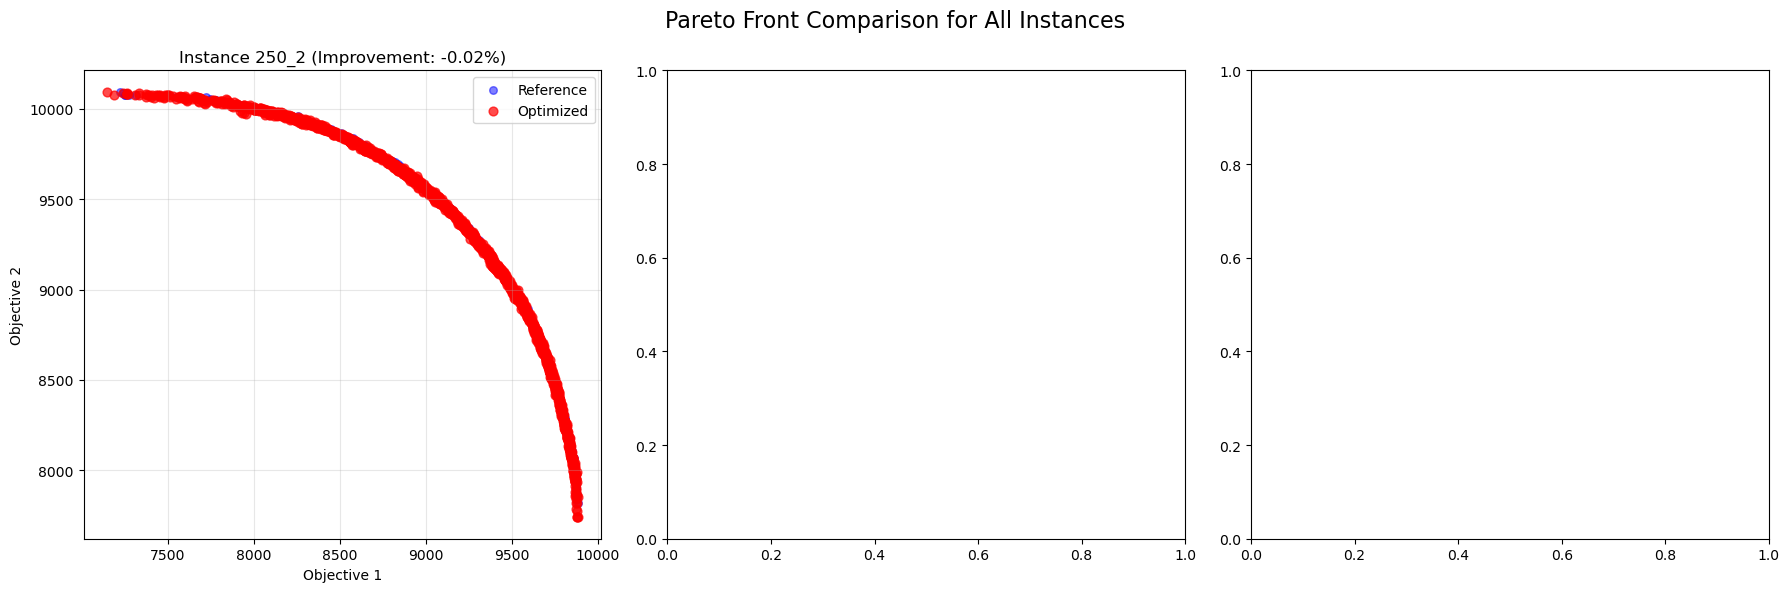


CORRECTED OPTIMIZATION SUMMARY REPORT

Instance 250_2:
  Reference HV: 98,522,052
  Final HV: 98,499,122
  Improvement: -0.02%
  Dominance Achieved: NO
  Best Config: {'alpha': 35, 'kappa': 0.12, 'L': 5, 'small_value': 1e-07, 'operator_strategy': ['swap', 'greedy_add', 'mutation'], 'runtime_threshold': 7.0}

🤖 LLM Statistics:
  Total calls: 0
  Successful calls: 15
  Failed calls: 0
  Success rate: 1500.0%

📊 Explored Configurations Statistics:
  250_2: 15 configurations explored
    Top 3 configurations:
      1. α=50, κ=0.200, L=8
         Performance: 98,499,122 (-0.02%)
      2. α=40, κ=0.180, L=8
         Performance: 98,495,818 (-0.03%)
      3. α=40, κ=0.180, L=7
         Performance: 98,494,893 (-0.03%)
  500_2: 5 configurations explored
    Top 3 configurations:
      1. α=50, κ=0.150, L=10
         Performance: 407,045,661 (0.07%)
      2. α=40, κ=0.180, L=8
         Performance: 406,773,730 (0.01%)
      3. α=50, κ=0.200, L=8
         Performance: 406,764,312 (0.00%)

✅ Cor

In [17]:

# Cell 8: Visualize Results for All Instances
def plot_pareto_comparison_all_instances(results_summary, reference_hvs):
    """Plot Pareto front comparison for all instances"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Pareto Front Comparison for All Instances', fontsize=16)
    
    for idx, (instance_sig, data) in enumerate(results_summary.items()):
        ax = axes[idx]
        
        # Get reference data
        reference_data = reference_hvs[instance_sig]
        reference_pareto = reference_data['pareto_solutions']
        
        # Plot reference solutions
        ax.scatter(reference_pareto[:, 0], reference_pareto[:, 1], 
                  c='blue', alpha=0.5, label='Reference', s=30)
        
        # Plot optimized solutions
        optimized_pareto = data['result']['pareto_solutions']
        ax.scatter(optimized_pareto[:, 0], optimized_pareto[:, 1], 
                  c='red', alpha=0.7, label='Optimized', s=40)
        
        ax.set_xlabel('Objective 1')
        ax.set_ylabel('Objective 2')
        ax.set_title(f"Instance {instance_sig} (Improvement: {data['improvement']:.2f}%)")
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pareto_comparison_all_instances.png', dpi=300)
    plt.show()

# Plot comparison for all instances
plot_pareto_comparison_all_instances(results_summary, reference_hvs)

# Cell 9: Summary Report
print("\n" + "="*60)
print("CORRECTED OPTIMIZATION SUMMARY REPORT")
print("="*60)

for instance_sig, data in results_summary.items():
    print(f"\nInstance {instance_sig}:")
    print(f"  Reference HV: {data['reference_hv']:,.0f}")
    print(f"  Final HV: {data['hv']:,.0f}")
    print(f"  Improvement: {data['improvement']:.2f}%")
    print(f"  Dominance Achieved: {'YES' if data['dominance_achieved'] else 'NO'}")
    print(f"  Best Config: {data['config']}")

# Show LLM statistics if available
if 'improved_llm_interface' in locals() and improved_llm_interface:
    print(f"\n🤖 LLM Statistics:")
    print(f"  Total calls: {improved_llm_interface.call_count}")
    print(f"  Successful calls: {improved_llm_interface.successful_calls}")
    print(f"  Failed calls: {improved_llm_interface.failed_calls}")
    print(f"  Success rate: {improved_llm_interface.successful_calls / max(1, improved_llm_interface.call_count) * 100:.1f}%")

# Show explored configurations statistics
print(f"\n📊 Explored Configurations Statistics:")
for instance_sig in corrected_optimizer.explored_configs:
    explored = corrected_optimizer.explored_configs[instance_sig]
    print(f"  {instance_sig}: {len(explored)} configurations explored")
    
    # Show top 3 configurations
    sorted_configs = sorted(explored.items(), key=lambda x: x[1]['performance'], reverse=True)
    print(f"    Top 3 configurations:")
    for i, (config_sig, data) in enumerate(sorted_configs[:3]):
        print(f"      {i+1}. α={data['config']['alpha']}, κ={data['config']['kappa']:.3f}, L={data['config']['L']}")
        print(f"         Performance: {data['performance']:,.0f} ({data['improvement']:.2f}%)")

print("\n✅ Corrected Instance-Specific Optimization Complete!")